# Analyse stratégique des données AfriMarket

**Entreprise :** AfriMarket — e-commerce panafricain (Électronique, Mode, Beauté, Maison)
**Auteur :** Data Analyst
**Période analysée :** 6 mois d'activité commerciale (juillet - décembre 2025)

**Objectif :** produire une analyse stratégique complète permettant à la direction de comprendre les variations de chiffre d'affaires, le taux de retour, les dépenses marketing et les écarts de performance entre villes, afin de prendre des décisions business argumentées.

---
## Sommaire
1. [Audit & compréhension des données](#1)
2. [Data cleaning](#2)
3. [Feature engineering](#3)
4. [Analyses](#4)
    - 4.1 Performance globale
    - 4.2 Analyse par catégorie
    - 4.3 Analyse géographique
    - 4.4 Analyse marketing
    - 4.5 Analyse clients
5. [Visualisations de synthèse](#5)
6. [Recommandations stratégiques & conclusion](#6)


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
%matplotlib inline


<a id="1"></a>
## 1. Audit & compréhension des données

On charge le fichier brut `afrimarket_dataset_senior.csv` (6 mois d'activité commerciale) et on explore sa structure avant tout traitement.

In [2]:
df_raw = pd.read_csv("data/afrimarket_dataset_senior.csv", encoding="utf-8")
print("Dimensions :", df_raw.shape)
df_raw.head()


Dimensions : (10100, 14)


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [3]:
# Types de données
df_raw.dtypes


id_commande             str
date_commande           str
id_client               str
ville                   str
categorie               str
nom_produit             str
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement        str
canal_marketing         str
cout_marketing      float64
statut_commande         str
dtype: object

In [4]:
# Valeurs manquantes (NaN explicites)
df_raw.isnull().sum()


id_commande         0
date_commande       0
id_client           0
ville               0
categorie           0
nom_produit         0
prix_unitaire       0
quantite            0
remise              0
cout_livraison      0
methode_paiement    0
canal_marketing     0
cout_marketing      0
statut_commande     0
dtype: int64

**Constat :** aucune valeur `NaN` explicite. Les erreurs de saisie sont en réalité encodées comme des valeurs *valides mais aberrantes* (prix négatifs, quantités nulles, remises négatives, doublons, orthographes incohérentes) — typique d'un jeu de données réel.

In [5]:
# Doublons
print("Lignes strictement dupliquées :", df_raw.duplicated().sum())
print("id_commande dupliqués :", df_raw.duplicated(subset=["id_commande"]).sum())


Lignes strictement dupliquées : 100
id_commande dupliqués : 100


In [6]:
# Valeurs aberrantes numériques
print("Prix unitaire < 0 :", (df_raw["prix_unitaire"] < 0).sum())
print("Quantité == 0 :", (df_raw["quantite"] == 0).sum())
print("Remise < 0 :", (df_raw["remise"] < 0).sum())
df_raw[["prix_unitaire", "quantite", "remise", "cout_livraison", "cout_marketing"]].describe()


Prix unitaire < 0 : 632
Quantité == 0 : 608
Remise < 0 : 614


,prix_unitaire,quantite,remise,cout_livraison,cout_marketing
count,"10,100.00","10,100.00","10,100.00","10,100.00","10,100.00"
mean,140.49,1.87,0.11,6.01,7.39
std,172.03,0.92,0.10,2.30,4.64
min,-50.00,0.00,-0.10,2.00,0.50
25%,28.06,1.00,0.05,4.04,3.98
50%,52.97,2.00,0.09,5.99,6.87
75%,201.88,3.00,0.19,8.03,10.85
max,915.86,3.00,0.30,10.00,19.98


**Diagnostic prix négatifs :** en isolant les prix négatifs, on constate que ~97% d'entre eux valent exactement **-50.00**, une valeur constante indépendante du produit concerné (ex. un article `Électronique` qui vaut normalement ~400 apparaît aussi à -50). Il ne s'agit donc pas d'une simple inversion de signe mais d'un **code d'erreur injecté** : on les traitera comme des valeurs manquantes à imputer.

**Diagnostic remises négatives :** à l'inverse, 100% des remises négatives valent exactement **-0.10**, une valeur plausible de remise (0 à 30% observé sur le reste du dataset). C'est cohérent avec une **simple inversion de signe** : on prendra la valeur absolue.

In [7]:
# Incohérences catégorielles
for c in ["ville", "categorie", "statut_commande"]:
    print(f"{c}: {sorted(df_raw[c].unique())}")


ville: ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Kinshassa', 'Libreville', 'Lomé']
categorie: ['Beauté', 'Maison', 'Mode', 'electronique', 'Électronique']
statut_commande: ['Annulée', 'Livrée', 'retournée']


**Incohérences identifiées :**
- `ville` : `"Kinshassa"` est une faute d'orthographe de `"Kinshasa"`.
- `categorie` : `"electronique"` (sans accent, minuscule) est la même catégorie que `"Électronique"`.
- `statut_commande` : `"retournée"` (minuscule) doit être harmonisé en `"Retournée"`.


<a id="2"></a>
## 2. Data Cleaning

On applique les corrections identifiées lors de l'audit pour produire un jeu de données propre `df_clean`. La logique est centralisée dans `src_pipeline.py` (fonction `clean_data`) pour être réutilisable par le dashboard Streamlit.

In [8]:
from src_pipeline import load_raw, clean_data, add_features

df_raw = load_raw()
df_clean = clean_data(df_raw)
print("Lignes avant nettoyage :", len(df_raw))
print("Lignes après suppression des doublons :", len(df_clean))


Lignes avant nettoyage : 10100
Lignes après suppression des doublons : 10000


In [9]:
# Vérification post-nettoyage
checks = {
    "prix_unitaire < 0": (df_clean["prix_unitaire"] < 0).sum(),
    "quantite == 0": (df_clean["quantite"] == 0).sum(),
    "remise < 0": (df_clean["remise"] < 0).sum(),
    "id_commande dupliqués": df_clean.duplicated(subset=["id_commande"]).sum(),
}
checks


{'prix_unitaire < 0': np.int64(0),
 'quantite == 0': np.int64(0),
 'remise < 0': np.int64(0),
 'id_commande dupliqués': np.int64(0)}

In [10]:
print("Villes :", sorted(df_clean["ville"].unique()))
print("Catégories :", sorted(df_clean["categorie"].unique()))
print("Statuts :", sorted(df_clean["statut_commande"].unique()))


Villes : ['Abidjan', 'Brazzaville', 'Cotonou', 'Dakar', 'Douala', 'Kinshasa', 'Libreville', 'Lomé']
Catégories : ['Beauté', 'Maison', 'Mode', 'Électronique']
Statuts : ['Annulée', 'Livrée', 'Retournée']


**Résumé des traitements appliqués :**

| Problème | Traitement | Justification |
|---|---|---|
| 100 commandes dupliquées (même `id_commande`) | Suppression des doublons (1ère occurrence conservée) | `id_commande` doit être unique |
| Prix unitaire négatif (632 lignes, ~97% = -50.00 constant) | Traité comme valeur manquante, imputé par la **médiane du même produit** | Valeur non corrélée au vrai prix du produit -> code d'erreur, pas une inversion de signe |
| Remise négative (614 lignes, 100% = -0.10 constant) | Valeur absolue | Constante plausible -> simple inversion de signe |
| Quantité nulle (608 lignes) | Traité comme valeur manquante, imputé par la **médiane de la catégorie** | Une commande à 0 article n'a pas de sens business |
| `"Kinshassa"` | Renommé en `"Kinshasa"` | Faute d'orthographe |
| `"electronique"` vs `"Électronique"` | Harmonisé en `"Électronique"` | Casse/accent incohérents |
| `"retournée"` vs `"Retournée"` | Harmonisé en `"Retournée"` | Casse incohérente |


<a id="3"></a>
## 3. Feature Engineering

On enrichit `df_clean` avec les variables business nécessaires aux analyses.

**Hypothèses de modélisation (documentées) :**
- `chiffre_affaires` = prix unitaire x quantité x (1 - remise)
- `marge_brute` = chiffre d'affaires x 45% (hypothèse de coût de revient à 55% du prix, non fourni dans les données)
- `profit_net` = marge brute - coût de livraison - coût marketing de la commande
- Les commandes **Annulées** sont exclues du chiffre d'affaires réel (aucune vente effective), mais le coût marketing déjà engagé reste comptabilisé dans les coûts.


In [11]:
df_clean = add_features(df_clean)
df_clean.to_csv("data/df_clean.csv", index=False, encoding="utf-8")
df_clean[["chiffre_affaires", "marge_brute", "profit_net", "mois", "indicateur_retour",
          "nombre_commandes_par_client", "valeur_vie_client"]].head()


,chiffre_affaires,marge_brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,138.72,62.42,58.97,2025-12,0,26,"9,144.90"
1,66.92,30.11,15.18,2025-07,0,4,562.87
2,605.95,272.68,259.78,2025-07,0,23,"6,511.17"
3,277.90,125.05,113.89,2025-08,0,5,764.75
4,977.47,439.86,434.15,2025-11,0,26,"9,516.06"


<a id="4"></a>
## 4. Analyses demandées

### 4.1 Performance globale

In [12]:
from src_analysis import performance_globale

perf = performance_globale(df_clean)
for k, v in perf.items():
    print(f"{k:20s}: {v}")


ca_total            : 2670518.96
profit_total        : 1070207.32
panier_moyen        : 272.31
taux_annulation     : 0.0193
taux_retour         : 0.0816
nb_commandes        : 10000
nb_clients          : 1772


### 4.2 Analyse par catégorie

In [13]:
from src_analysis import analyse_categorie, evolution_mensuelle_categorie

cat_agg = analyse_categorie(df_clean)
cat_agg


,categorie,ca,marge,profit,nb_commandes,taux_retour
3,Électronique,"1,991,810.32","896,314.24","854,214.91",3148,0.14
1,Maison,"401,543.70","180,694.64","155,482.72",1883,0.05
2,Mode,"195,076.27","87,783.93","48,811.86",2921,0.07
0,Beauté,"82,088.67","36,939.75","11,697.83",1855,0.03


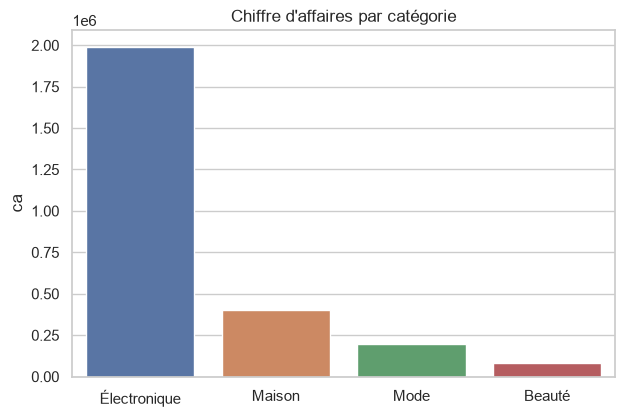

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=cat_agg, x="categorie", y="ca", hue="categorie", legend=False, ax=ax)
ax.set_title("Chiffre d'affaires par catégorie")
ax.set_xlabel("")
plt.show()


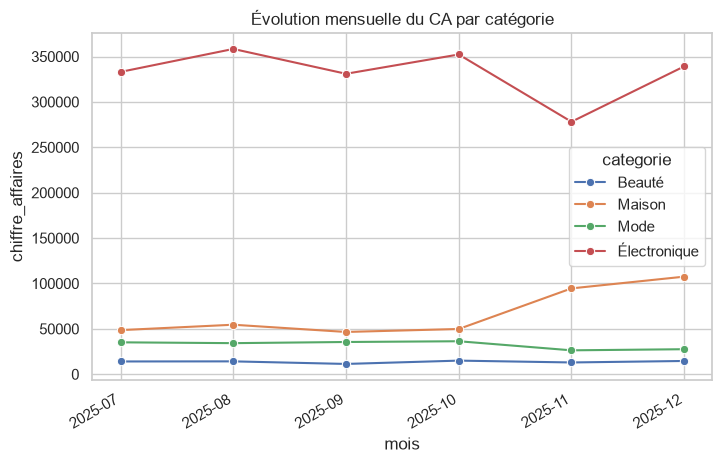

In [15]:
monthly_cat = evolution_mensuelle_categorie(df_clean)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=monthly_cat, x="mois", y="chiffre_affaires", hue="categorie", marker="o", ax=ax)
ax.set_title("Évolution mensuelle du CA par catégorie")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.show()


**Question stratégique — Quelle catégorie doit être priorisée ou optimisée ?**

`Électronique` génère à elle seule ~75% du CA total et domine largement le profit net. C'est la catégorie à **prioriser en stock et en visibilité**. Mais elle affiche aussi le taux de retour le plus élevé (≈14%, contre 2 à 7% pour les autres catégories) : c'est la catégorie à **optimiser en priorité sur la qualité/fiabilité produit**, car chaque point de retour y coûte proportionnellement bien plus cher qu'ailleurs.

### 4.3 Analyse géographique

In [16]:
from src_analysis import analyse_ville, croissance_mensuelle_ville

ville_agg = analyse_ville(df_clean)
ville_agg


,ville,ca,profit,nb_commandes,taux_annulation
5,Kinshasa,"810,103.88","325,655.65",2909,0.00
0,Abidjan,"534,444.58","215,280.02",1871,0.00
3,Dakar,"372,083.67","148,518.95",1422,0.00
4,Douala,"343,701.44","137,812.50",1248,0.13
7,Lomé,"196,231.54","78,433.59",730,0.00
2,Cotonou,"169,057.91","67,299.55",671,0.00
6,Libreville,"130,084.46","51,689.02",492,0.00
1,Brazzaville,"114,811.48","45,518.04",464,0.00


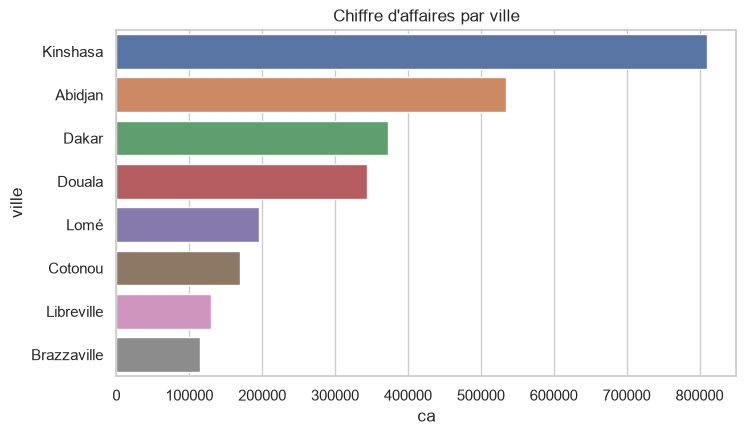

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=ville_agg, y="ville", x="ca", hue="ville", legend=False, ax=ax)
ax.set_title("Chiffre d'affaires par ville")
plt.show()


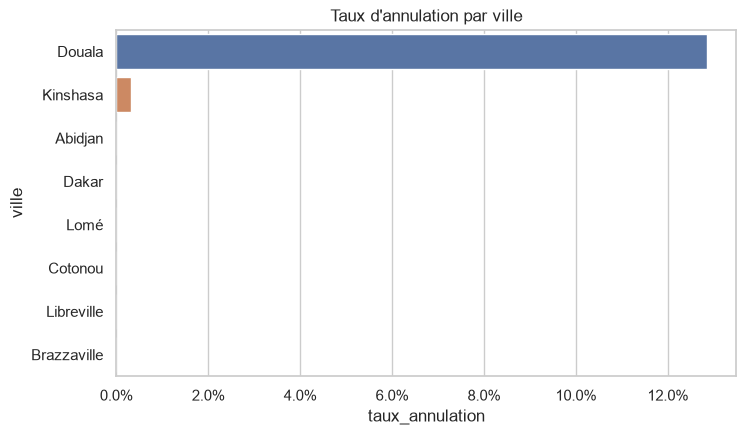

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=ville_agg.sort_values("taux_annulation", ascending=False), y="ville", x="taux_annulation",
            hue="ville", legend=False, ax=ax)
ax.set_title("Taux d'annulation par ville")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.show()


**Question stratégique — Où devons-nous investir davantage ?**

`Kinshasa` est la ville la plus performante (CA et profit les plus élevés, taux d'annulation quasi nul) : elle mérite un **renforcement de l'investissement** (stock, marketing local). À l'inverse, `Douala` combine un CA/profit correct mais un **taux d'annulation anormalement élevé (~12.8%)**, contre quasiment 0% ailleurs — un signal opérationnel local (logistique, paiement, expérience client) à investiguer avant d'investir davantage dans cette ville.

### 4.4 Analyse marketing

In [19]:
from src_analysis import analyse_marketing

mkt_agg = analyse_marketing(df_clean)
mkt_agg


,canal_marketing,ca,cout_marketing,roi,taux_retention
0,Email,"569,904.34","2,511.28",225.94,0.93
1,Google Ads,"698,739.00","13,891.18",49.30,0.92
3,Instagram Ads,"1,011,474.90","40,049.73",24.26,0.91
2,Influenceur,"390,400.72","17,434.73",21.39,0.92


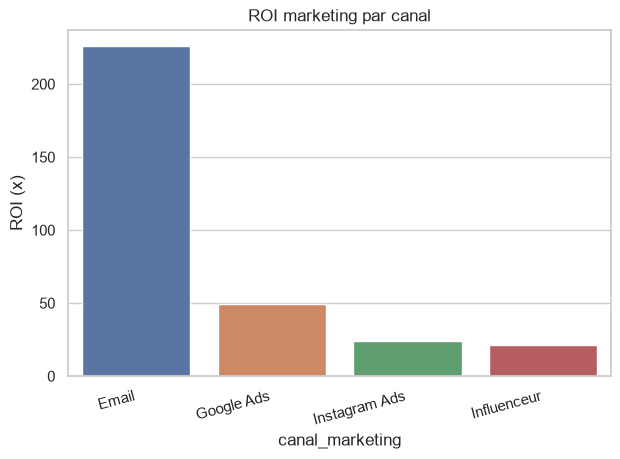

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=mkt_agg, x="canal_marketing", y="roi", hue="canal_marketing", legend=False, ax=ax)
ax.set_title("ROI marketing par canal")
ax.set_ylabel("ROI (x)")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()


**Formule ROI :** `ROI = (Revenus - Coût marketing) / Coût marketing`

**Question stratégique — Quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?**

`Email` a de très loin le meilleur ROI (~226x) pour un coût marketing très faible : c'est un canal **sous-exploité à renforcer en priorité** (quick win, coût marginal faible). `Instagram Ads` génère le plus de CA en absolu et capte le budget le plus élevé, mais avec un ROI modeste (~24x) : c'est le plus gros gisement d'optimisation en valeur absolue, ce canal doit être **optimisé (ciblage, créa) plutôt que simplement augmenté en budget**. `Influenceur` affiche le ROI le plus faible en proportion (~21x), sur un budget plus restreint.

### 4.5 Analyse clients

In [21]:
from src_analysis import analyse_clients, pareto_clients, segmentation_clients

clients_info = analyse_clients(df_clean)
print("Nombre total de clients :", clients_info["nb_clients"])
print("% clients récurrents (>1 commande) :", f'{clients_info["pct_recurrents"]:.1%}')
clients_info["top10"]


Nombre total de clients : 1772
% clients récurrents (>1 commande) : 75.5%


,id_client,chiffre_affaires
0,C0157,"11,783.36"
1,C0051,"11,257.45"
2,C0266,"10,673.23"
3,C0120,"9,542.19"
4,C0003,"9,516.06"
5,C0364,"9,396.79"
6,C0024,"9,234.65"
7,C0379,"9,144.90"
8,C0114,"8,915.44"
9,C0001,"8,516.45"


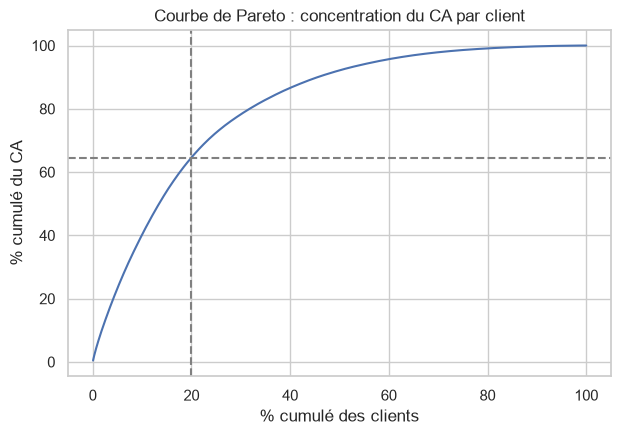

Les 20% meilleurs clients génèrent 64.5% du CA


In [22]:
pareto, part_top20 = pareto_clients(df_clean)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(pareto["cum_pct_clients"], pareto["cum_pct_ca"])
ax.axvline(20, color="grey", linestyle="--")
ax.axhline(part_top20, color="grey", linestyle="--")
ax.set_title("Courbe de Pareto : concentration du CA par client")
ax.set_xlabel("% cumulé des clients")
ax.set_ylabel("% cumulé du CA")
plt.show()
print(f"Les 20% meilleurs clients génèrent {part_top20}% du CA")


In [23]:
seg = segmentation_clients(df_clean)
seg["segment"].value_counts()


segment
Récurrent      965
Occasionnel    442
VIP            352
Name: count, dtype: int64

**Question stratégique — Comment améliorer la rétention ?**

75% des clients sont déjà récurrents (>1 commande) et les 20% meilleurs clients concentrent **64.5%** du CA : la base de fidélisation est solide mais **concentrée sur un noyau de clients VIP**. La priorité est un programme de fidélité ciblé sur le segment VIP (352 clients) pour sécuriser cette rente, et une séquence de relance dédiée au segment "Occasionnel" (442 clients, une seule commande) pour les convertir en récurrents.

<a id="5"></a>
## 5. Visualisations complémentaires

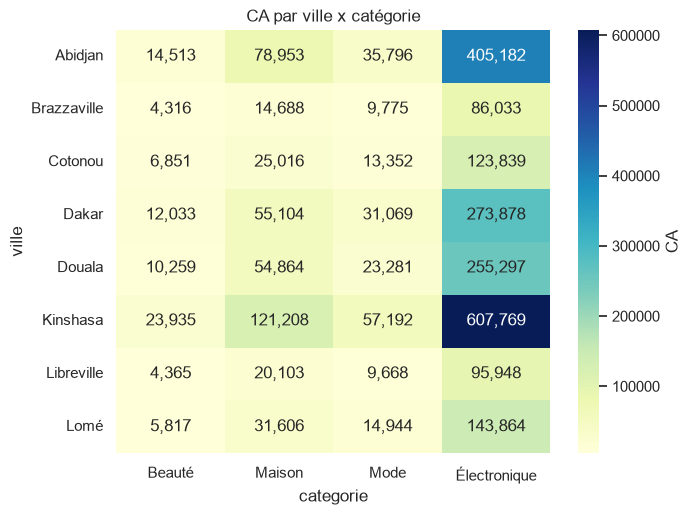

In [24]:
fig, ax = plt.subplots(figsize=(7, 5.5))
pivot = df_clean[df_clean["statut_commande"] != "Annulée"].pivot_table(
    index="ville", columns="categorie", values="chiffre_affaires", aggfunc="sum", fill_value=0)
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax, cbar_kws={"label": "CA"})
ax.set_title("CA par ville x catégorie")
plt.show()


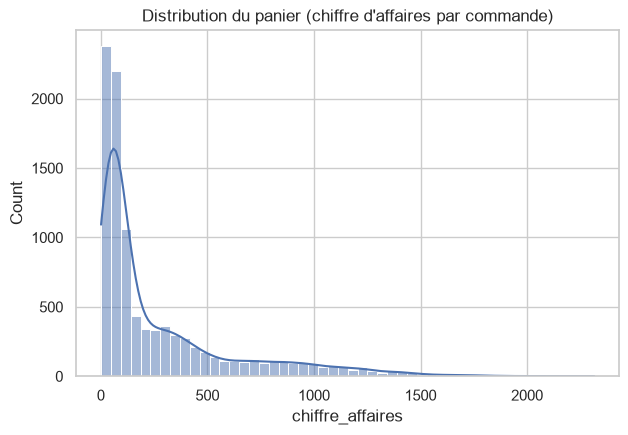

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(df_clean.loc[df_clean["statut_commande"] != "Annulée", "chiffre_affaires"], bins=50, kde=True, ax=ax)
ax.set_title("Distribution du panier (chiffre d'affaires par commande)")
plt.show()


<a id="6"></a>
## 6. Recommandations stratégiques & conclusion

Voir le résumé exécutif (`reports/resume_executif.md`) pour les 5 recommandations stratégiques détaillées et la conclusion business orientée action. En synthèse :

1. **Prioriser Électronique en stock/visibilité, tout en engageant un plan qualité** pour faire baisser son taux de retour (14%).
2. **Renforcer l'investissement à Kinshasa** (meilleure ville) et **auditer les causes d'annulation à Douala** (12.8% vs ~0% ailleurs) avant tout investissement supplémentaire.
3. **Réallouer une partie du budget Instagram Ads vers Email**, qui offre un ROI ~9x supérieur pour un coût marginal.
4. **Lancer un programme de fidélisation VIP** pour sécuriser les 20% de clients qui génèrent 64.5% du CA.
5. **Mettre en place une séquence de relance pour les clients occasionnels** (442 clients à une seule commande) afin d'augmenter le taux de clients récurrents.
